# MISMIP transient visualisation examples

This notebook explores `/g/data/au88/jr5971/MISMIP_ISSM/rundir/10km_viscous_loaded.issm.nc` directly from its NetCDF result group. It follows the matplotlib-style plotting pattern used in the local pyISSM tutorials, but keeps the time dimension explicit so each saved output step can be inspected, compared, and animated.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.tri as mtri
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import netCDF4 as nc
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

NC_PATH = Path('/g/data/au88/jr5971/MISMIP_ISSM/rundir/10km_viscous_loaded.issm.nc')
OUTLOG_PATH = Path('/scratch/au88/jr5971/issm_runs/MISMIP_10km_viscous_Tss1-200y/MISMIP_10km_viscous_Tss1-200y.outlog')
assert NC_PATH.exists(), NC_PATH

## Load mesh and transient fields

ISSM stores triangular elements using 1-based indexing. Matplotlib needs 0-based indexing, so the cell below converts the mesh once and loads each 2-D result variable as `[time, vertex]`.

In [2]:
def load_mismip_result(path):
    with nc.Dataset(path) as ds:
        mesh = ds.groups['mesh']
        result = ds.groups['results'].groups['TransientSolution']

        x = np.asarray(mesh.variables['x'][:], dtype=float)
        y = np.asarray(mesh.variables['y'][:], dtype=float)
        elements = np.asarray(mesh.variables['elements'][:], dtype=int) - 1
        triang = mtri.Triangulation(x, y, elements)

        time = np.asarray(result.variables['time'][:], dtype=float)
        step = np.asarray(result.variables['step'][:], dtype=int)
        fields = {}
        for name, var in result.variables.items():
            arr = np.asarray(var[:])
            if arr.ndim == 2 and arr.shape[1] == x.size:
                fields[name] = arr.astype(float)

        attrs = {attr: result.getncattr(attr) for attr in result.ncattrs()}

    return x, y, elements, triang, time, step, fields, attrs

x, y, elements, triang, time, step, fields, result_attrs = load_mismip_result(NC_PATH)
print(f"Loaded {NC_PATH.name}")
print(f"vertices={x.size}, elements={elements.shape[0]}, saved outputs={time.size}")
print(f"saved times [yr]: {time}")
print(f"result fields: {', '.join(fields)}")

Loaded 10km_viscous_loaded.issm.nc
vertices=646, elements=1146, saved outputs=11
saved times [yr]: [  1.  20.  40.  60.  80. 100. 120. 140. 160. 180. 200.]
result fields: Base, MaskOceanLevelset, Pressure, SmbMassBalance, Surface, Thickness, Vel, Vx, Vy


## Optional pyISSM plotting style

The local tutorials use `pyissm.plot.plot_mesh2d()` and `pyissm.plot.plot_model_field()` on a loaded model object. This direct-NetCDF notebook does not depend on pyISSM, but the saved file can also be loaded as a pyISSM model if you want to use the same tutorial helpers for individual snapshots.

ℹ️ Processing results group: TransientSolution


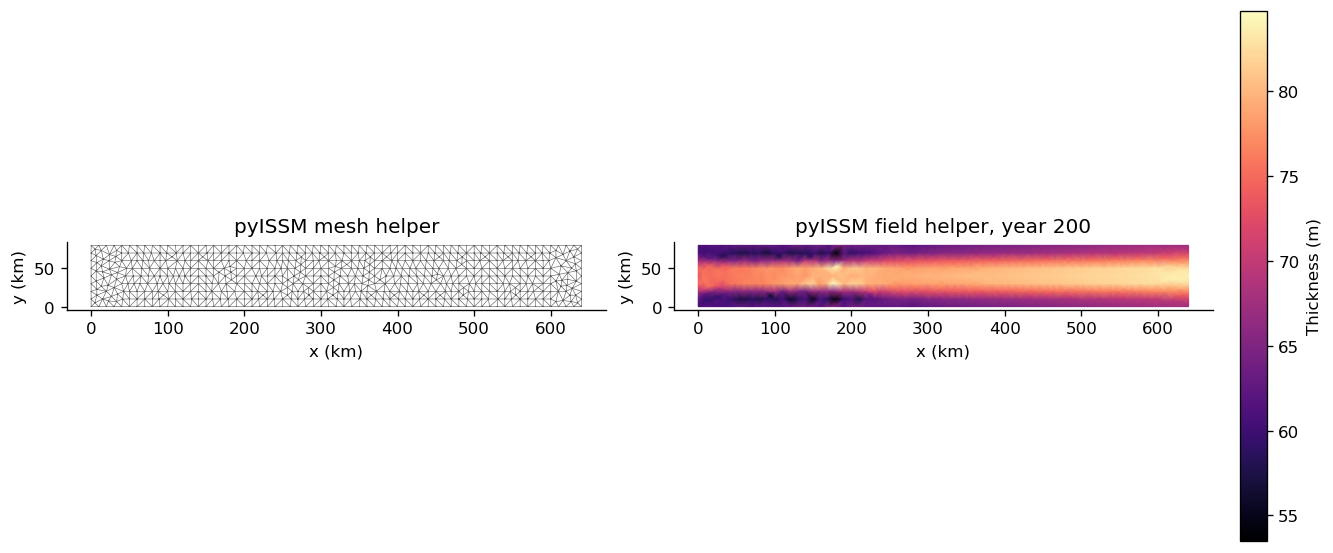

In [3]:
import sys
sys.path.insert(0, '/g/data/au88/jr5971/pyISSM/src')

try:
    import pyissm
    md = pyissm.model.io.load_model(str(NC_PATH))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
    pyissm.plot.plot_mesh2d(md, ax=axes[0], color='0.35', linewidth=0.35, xlabel='x (km)', ylabel='y (km)')
    pyissm.plot.plot_model_field(
        md,
        md.results.TransientSolution.Thickness[-1],
        ax=axes[1],
        cmap='magma',
        show_cbar=True,
        cbar_kwargs={'label': 'Thickness (m)'},
        xlabel='x (km)',
        ylabel='y (km)',
    )
    pyissm_km_formatter = mticker.FuncFormatter(lambda value, _: f'{value/1000:.0f}')
    for ax in axes:
        ax.xaxis.set_major_formatter(pyissm_km_formatter)
        ax.yaxis.set_major_formatter(pyissm_km_formatter)
        ax.set_aspect('equal')
    axes[0].set_title('pyISSM mesh helper')
    axes[1].set_title(f'pyISSM field helper, year {md.results.TransientSolution.time[-1]:g}')
    plt.show()
except Exception as err:
    print(f'pyISSM optional example skipped: {err}')

In [4]:
def field_summary(fields, time):
    rows = []
    for name, arr in fields.items():
        rows.append({
            'field': name,
            'shape': str(arr.shape),
            'min': np.nanmin(arr),
            'max': np.nanmax(arr),
            'mean first output': np.nanmean(arr[0]),
            'mean final output': np.nanmean(arr[-1]),
            'mean change': np.nanmean(arr[-1] - arr[0]),
        })
    return pd.DataFrame(rows).set_index('field')

summary = field_summary(fields, time)
display(summary.style.format(precision=3))

,shape,min,max,mean first output,mean final output,mean change
field,,,,,,
Base,"(11, 646)",-75.675,349.832,24.698,-19.042,-43.741
MaskOceanLevelset,"(11, 646)",-791.448,453.065,-301.858,-242.426,59.432
Pressure,"(11, 646)",57575.731,4856547.528,1539723.074,638198.126,-901524.948
SmbMassBalance,"(11, 646)",0.300,0.300,0.300,0.300,0.000
Surface,"(11, 646)",0.307,411.146,36.500,52.192,15.692
Thickness,"(11, 646)",1.000,84.743,11.802,71.234,59.432
Vel,"(11, 646)",0.000,6055636.156,5297143.814,18.053,-5297125.761
Vx,"(11, 646)",-1.521,6055636.156,5294912.254,16.219,-5294896.035
Vy,"(11, 646)",-390225.886,407994.526,28.638,-0.025,-28.663


## Plotting helpers

These helpers use `tripcolor` on the ISSM mesh. `robust=True` clips colour limits to central percentiles, which is useful here because the first saved velocity field is much larger than later outputs.

In [5]:
km_formatter = mticker.FuncFormatter(lambda value, _: f'{value/1000:.0f}')

UNITS = {
    'Base': 'm',
    'Surface': 'm',
    'Thickness': 'm',
    'Pressure': 'Pa',
    'Vel': 'm/yr',
    'Vx': 'm/yr',
    'Vy': 'm/yr',
    'SmbMassBalance': 'm/yr ice equivalent',
    'MaskOceanLevelset': 'm',
}

def limits_for(arr, robust=False, q=(2, 98), symmetric=False):
    data = np.asarray(arr, dtype=float)
    data = data[np.isfinite(data)]
    if data.size == 0:
        return None, None
    if robust:
        vmin, vmax = np.nanpercentile(data, q)
    else:
        vmin, vmax = np.nanmin(data), np.nanmax(data)
    if symmetric:
        bound = np.nanmax(np.abs([vmin, vmax]))
        vmin, vmax = -bound, bound
    if np.isclose(vmin, vmax):
        pad = 1 if np.isclose(vmin, 0) else abs(vmin) * 0.05
        vmin, vmax = vmin - pad, vmax + pad
    return float(vmin), float(vmax)

def style_map_axis(ax, title=None):
    ax.set_aspect('equal')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.xaxis.set_major_formatter(km_formatter)
    ax.yaxis.set_major_formatter(km_formatter)
    if title:
        ax.set_title(title)

def plot_field_at_time(field, index=-1, ax=None, robust=True, cmap='viridis', show_mesh=False, show_grounding=True, **kwargs):
    arr = fields[field][index]
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    else:
        fig = ax.figure

    vmin, vmax = limits_for(arr, robust=robust, symmetric=kwargs.pop('symmetric', False))
    mesh_alpha = kwargs.pop('mesh_alpha', 0.15)
    image = ax.tripcolor(triang, arr, shading='gouraud', cmap=cmap, vmin=vmin, vmax=vmax, **kwargs)
    if show_mesh:
        ax.triplot(triang, color='k', linewidth=0.25, alpha=mesh_alpha)
    if show_grounding and 'MaskOceanLevelset' in fields:
        try:
            ax.tricontour(triang, fields['MaskOceanLevelset'][index], levels=[0], colors='black', linewidths=0.8)
        except Exception as err:
            warnings.warn(f'Could not draw MaskOceanLevelset=0 contour: {err}')
    unit = UNITS.get(field, '')
    label = f'{field} ({unit})' if unit else field
    fig.colorbar(image, ax=ax, label=label, shrink=0.9)
    style_map_axis(ax, f'{field}, year {time[index]:g}')
    return fig, ax

def plot_time_panels(field, indices=None, robust=True, cmap='viridis', show_grounding=True):
    if indices is None:
        indices = np.linspace(0, len(time)-1, min(6, len(time)), dtype=int)
    data = fields[field][indices]
    vmin, vmax = limits_for(data, robust=robust)
    ncols = min(3, len(indices))
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6*ncols, 3.8*nrows), constrained_layout=True, squeeze=False)
    image = None
    for ax, idx in zip(axes.ravel(), indices):
        image = ax.tripcolor(triang, fields[field][idx], shading='gouraud', cmap=cmap, vmin=vmin, vmax=vmax)
        if show_grounding and 'MaskOceanLevelset' in fields:
            ax.tricontour(triang, fields['MaskOceanLevelset'][idx], levels=[0], colors='black', linewidths=0.7)
        style_map_axis(ax, f'year {time[idx]:g}')
    for ax in axes.ravel()[len(indices):]:
        ax.axis('off')
    fig.colorbar(image, ax=axes, label=f'{field} ({UNITS.get(field, "")})', shrink=0.85)
    fig.suptitle(f'{field} through saved output steps', y=1.02)
    return fig, axes

def plot_change(field, start=0, end=-1, robust=True, cmap='RdBu_r'):
    delta = fields[field][end] - fields[field][start]
    vmin, vmax = limits_for(delta, robust=robust, symmetric=True)
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    image = ax.tripcolor(triang, delta, shading='gouraud', cmap=cmap, vmin=vmin, vmax=vmax)
    if 'MaskOceanLevelset' in fields:
        ax.tricontour(triang, fields['MaskOceanLevelset'][end], levels=[0], colors='black', linewidths=0.8)
    fig.colorbar(image, ax=ax, label=f'delta {field} ({UNITS.get(field, "")})')
    style_map_axis(ax, f'{field}: year {time[end]:g} minus year {time[start]:g}')
    return fig, ax

## Mesh and final-state overview

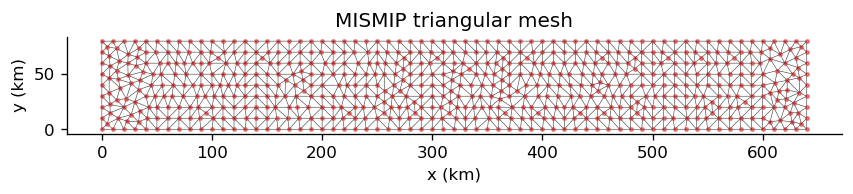

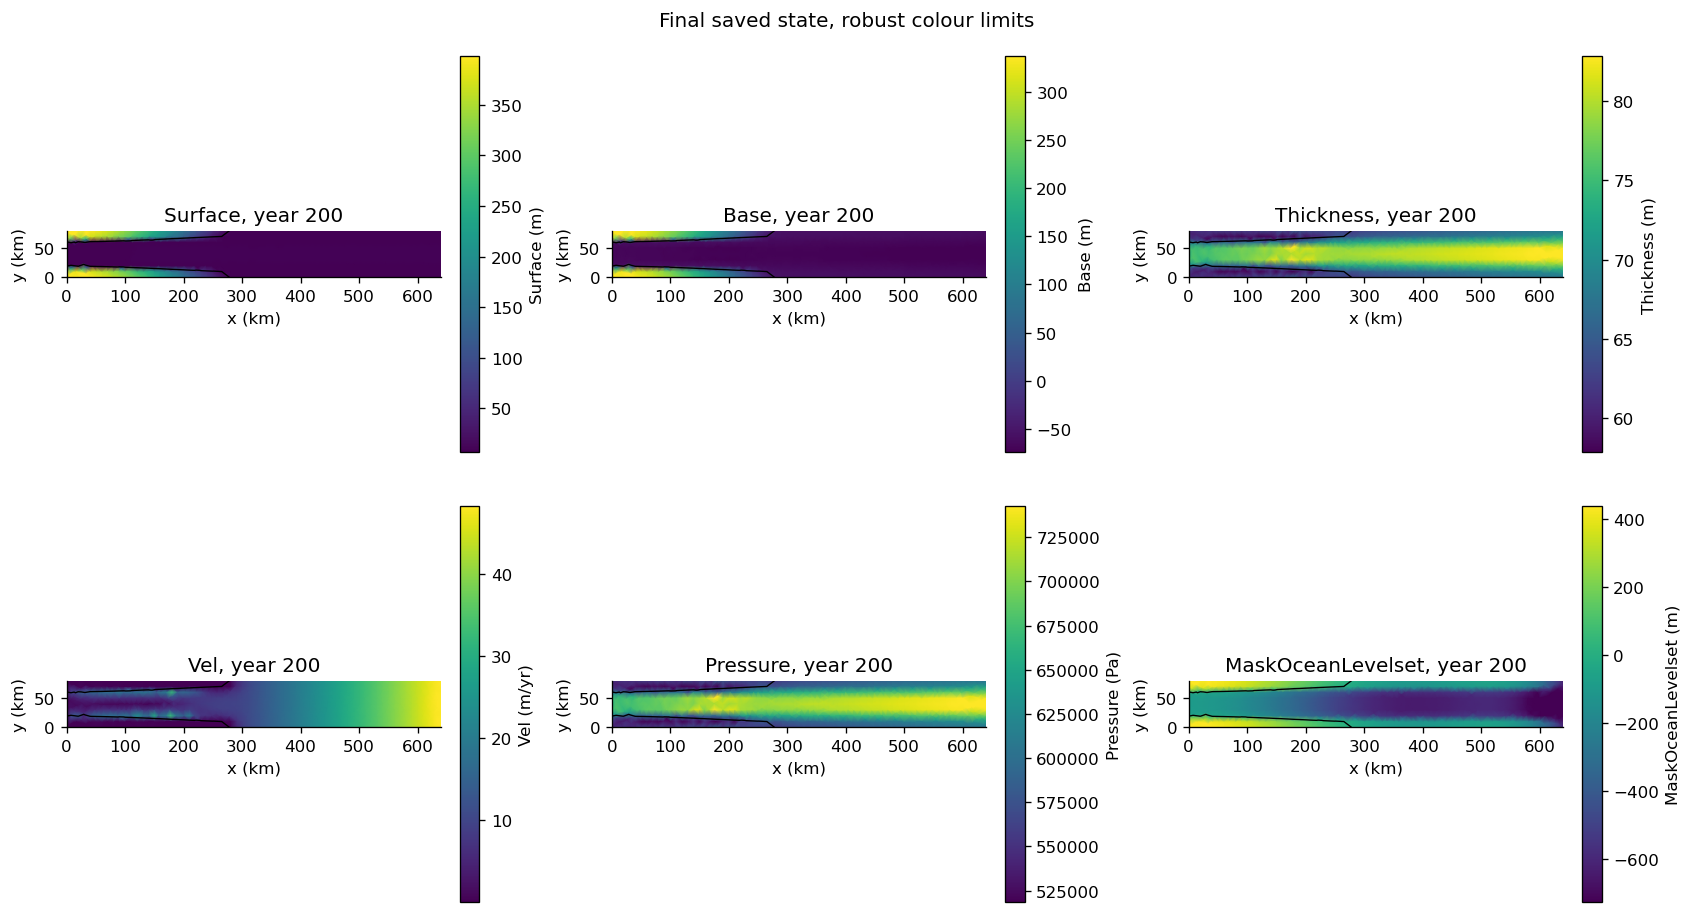

In [6]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.triplot(triang, color='0.25', linewidth=0.35)
ax.scatter(x, y, s=4, color='tab:red', alpha=0.5)
style_map_axis(ax, 'MISMIP triangular mesh')
plt.show()

overview_fields = ['Surface', 'Base', 'Thickness', 'Vel', 'Pressure', 'MaskOceanLevelset']
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), constrained_layout=True)
for ax, field in zip(axes.ravel(), overview_fields):
    plot_field_at_time(field, index=-1, ax=ax, robust=True, show_grounding=True)
fig.suptitle('Final saved state, robust colour limits', y=1.02)
plt.show()

## Time-step panels

Change `field` to any of the result variables listed in the summary table. For velocity, robust limits keep the late-time spatial structure visible despite the very large first saved field.

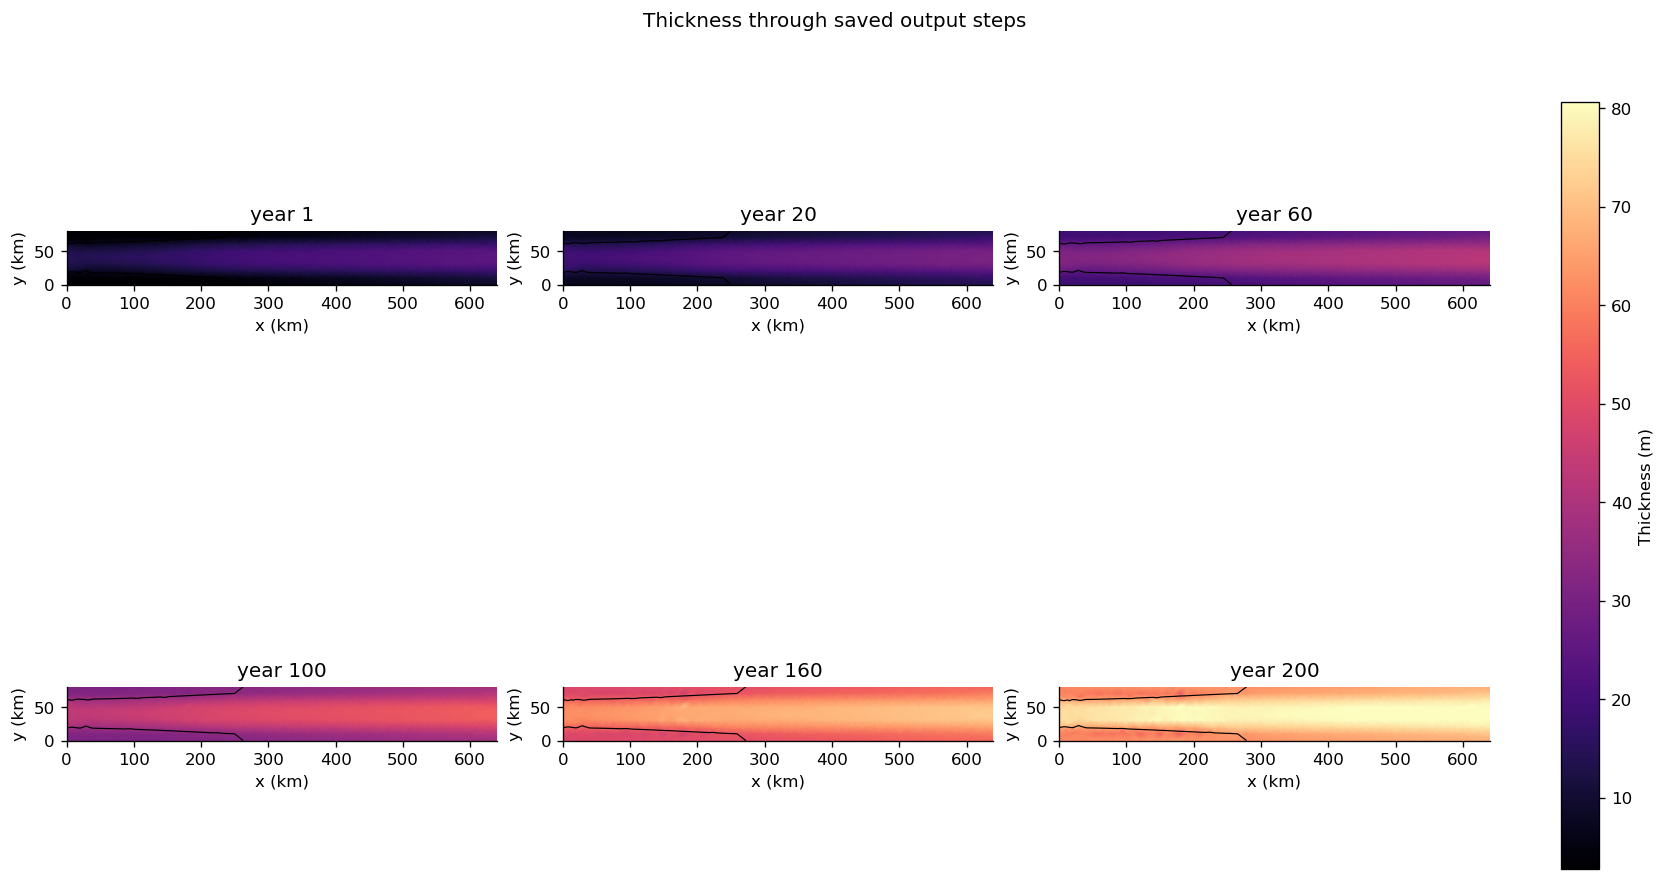

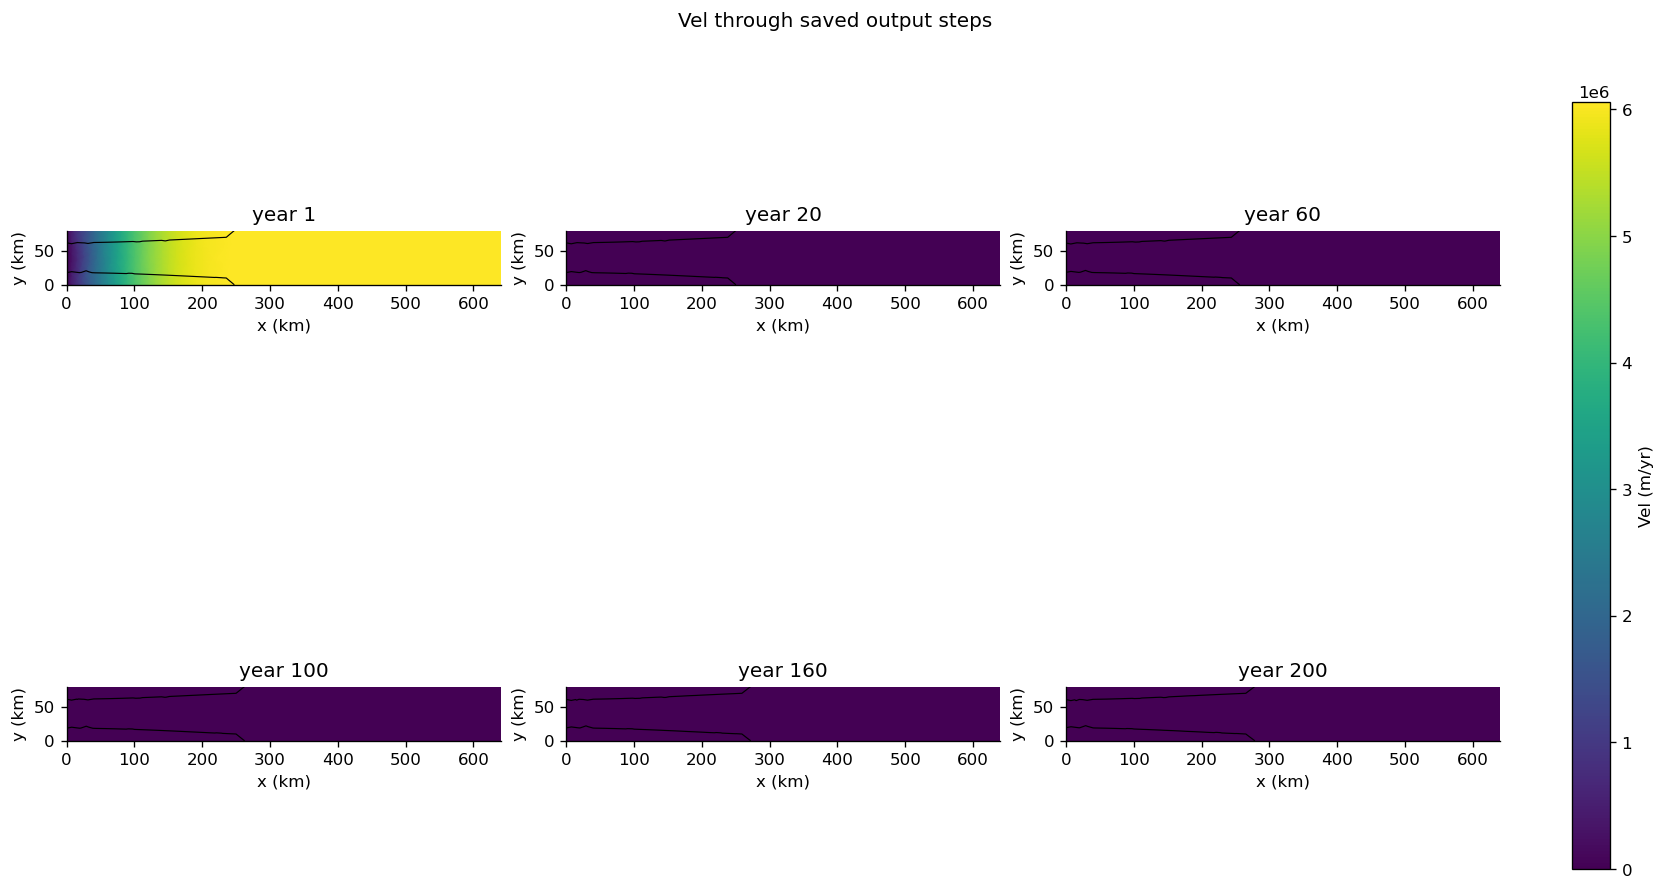

In [7]:
plot_time_panels('Thickness', indices=[0, 1, 3, 5, 8, 10], robust=True, cmap='magma')
plt.show()

plot_time_panels('Vel', indices=[0, 1, 3, 5, 8, 10], robust=True, cmap='viridis')
plt.show()

## Change maps

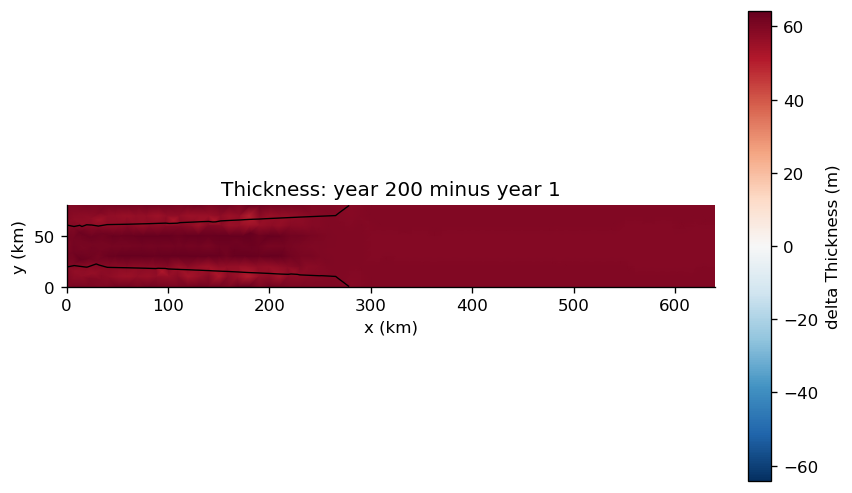

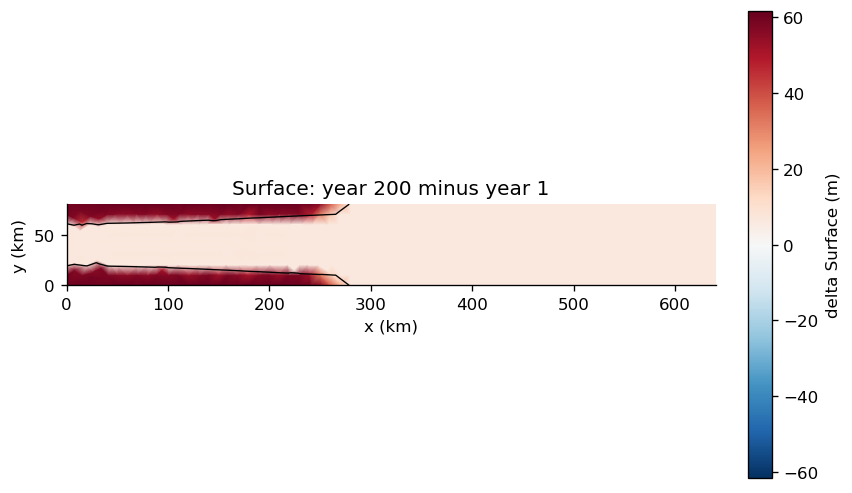

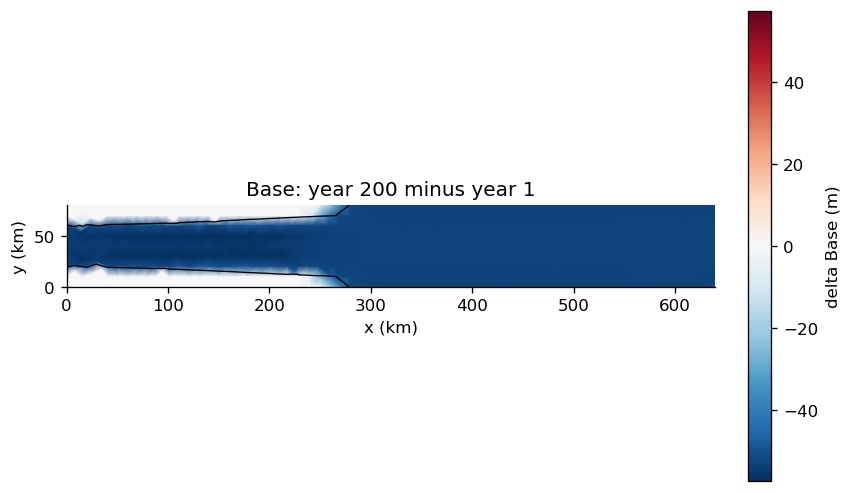

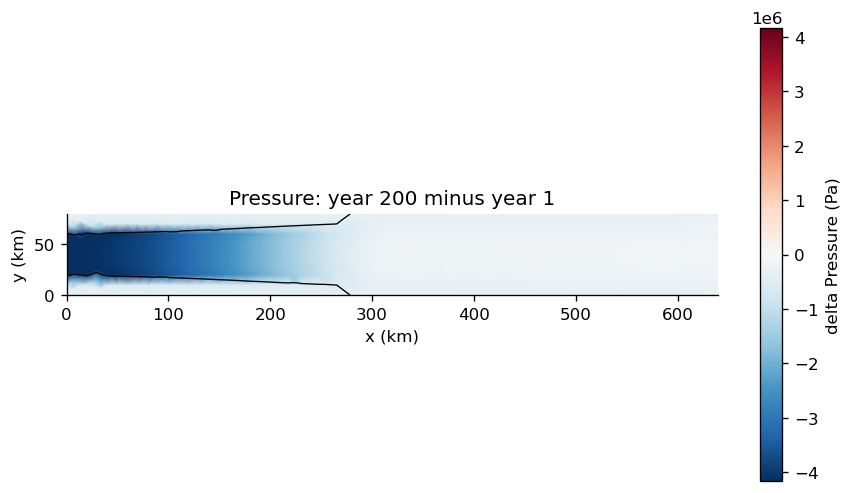

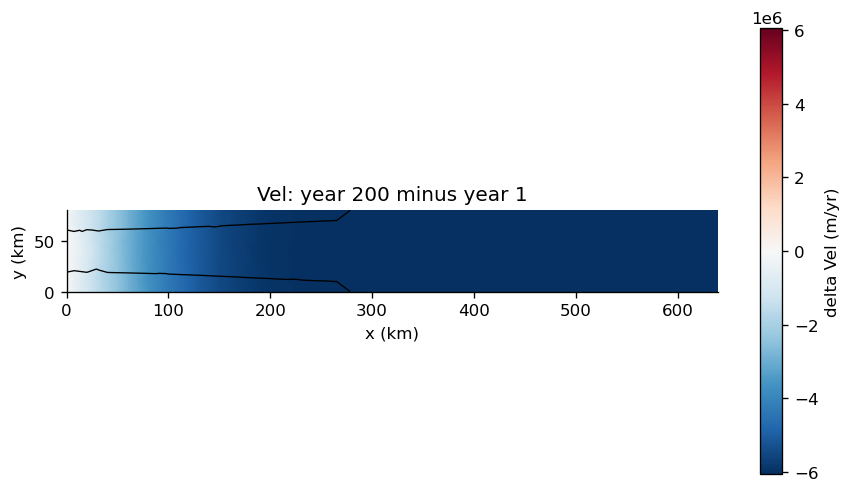

In [8]:
for field in ['Thickness', 'Surface', 'Base', 'Pressure', 'Vel']:
    plot_change(field, start=0, end=-1, robust=True)
    plt.show()

## Domain statistics through time

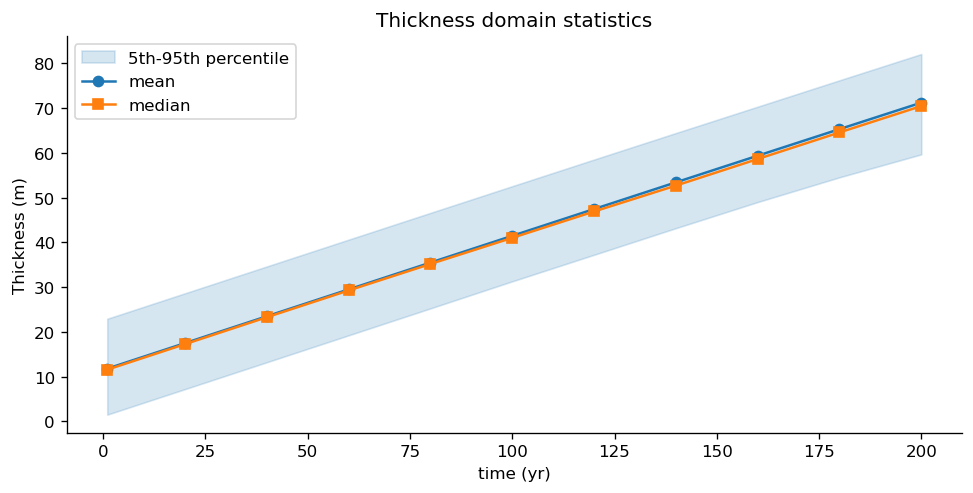

,time_yr,mean,median,p05,p95,min,max
0,1.0,11.802,11.570,1.518,22.942,1.000,25.051
1,20.0,17.501,17.273,7.219,28.639,6.700,30.746
2,40.0,23.499,23.288,13.224,34.634,12.699,36.737
3,60.0,29.496,29.269,19.239,40.623,18.697,42.719
4,80.0,35.489,35.183,25.257,46.604,24.693,48.689
5,100.0,41.477,41.026,31.304,52.572,30.686,54.641
6,120.0,47.458,46.914,37.237,58.522,36.677,60.569
7,140.0,53.427,52.701,43.185,64.447,41.730,66.465
8,160.0,59.382,58.641,49.020,70.338,46.086,72.320
9,180.0,65.320,64.582,54.549,76.231,50.011,78.123


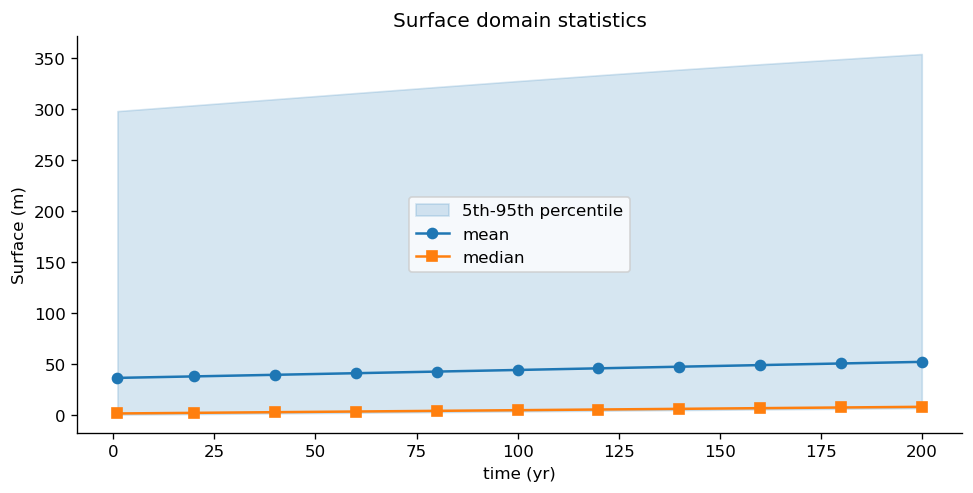

,time_yr,mean,median,p05,p95,min,max
0,1.0,36.500,1.672,0.526,297.688,0.307,351.076
1,20.0,37.962,2.282,1.149,303.387,0.930,356.776
2,40.0,39.522,2.938,1.792,309.378,1.571,362.775
3,60.0,41.097,3.594,2.436,315.347,2.212,368.773
4,80.0,42.672,4.238,3.077,321.267,2.851,374.772
5,100.0,44.256,4.889,3.733,327.099,3.503,380.774
6,120.0,45.853,5.548,4.379,332.795,4.137,386.784
7,140.0,47.441,6.198,5.013,338.296,4.766,392.812
8,160.0,49.028,6.868,5.667,343.542,5.401,398.869
9,180.0,50.616,7.527,6.298,348.558,6.013,404.973


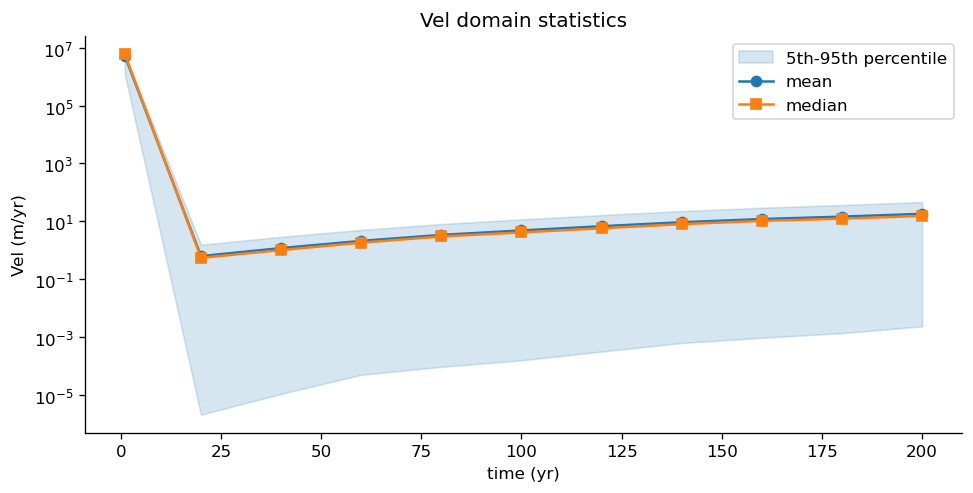

,time_yr,mean,median,p05,p95,min,max
0,1.0,5297143.814,6055577.768,1212248.803,6055631.437,0.0,6055636.156
1,20.0,0.623,0.543,0.000,1.539,0.0,3.317
2,40.0,1.182,1.007,0.000,2.889,0.0,6.190
3,60.0,2.092,1.822,0.000,5.015,0.0,9.453
4,80.0,3.377,2.981,0.000,8.026,0.0,12.936
5,100.0,4.805,4.118,0.000,11.615,0.0,16.501
6,120.0,6.737,5.712,0.000,16.308,0.0,20.050
7,140.0,9.253,7.944,0.001,22.455,0.0,24.184
8,160.0,11.895,10.315,0.001,29.255,0.0,31.563
9,180.0,14.455,12.291,0.001,36.528,0.0,39.474


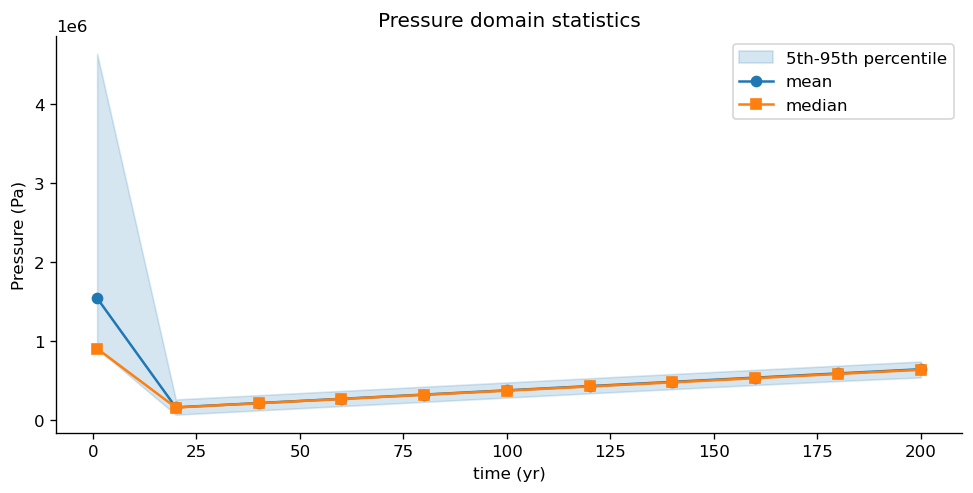

,time_yr,mean,median,p05,p95,min,max
0,1.0,1539723.074,899640.000,899640.000,4637200.557,899640.000,4856547.528
1,20.0,154749.154,152691.647,62248.502,254953.079,57575.731,273908.880
2,40.0,208713.038,206794.498,116269.627,308884.138,111550.140,327803.888
3,60.0,262660.265,260627.039,170376.820,362769.357,165512.357,381627.330
4,80.0,316578.212,313879.458,224515.396,416580.264,219454.278,435341.526
5,100.0,370450.702,366470.887,278860.726,470278.882,273370.172,488898.914
6,120.0,424259.365,419421.874,332493.838,523816.693,327263.788,542241.607
7,140.0,477971.913,471468.128,385846.225,577131.391,373359.931,595299.743
8,160.0,531551.906,524894.269,438469.902,630148.149,412739.117,647992.755
9,180.0,584978.820,578253.000,488157.259,683183.510,448250.637,700228.750


In [9]:
def timeseries_stats(field):
    arr = fields[field]
    return pd.DataFrame({
        'time_yr': time,
        'mean': np.nanmean(arr, axis=1),
        'median': np.nanmedian(arr, axis=1),
        'p05': np.nanpercentile(arr, 5, axis=1),
        'p95': np.nanpercentile(arr, 95, axis=1),
        'min': np.nanmin(arr, axis=1),
        'max': np.nanmax(arr, axis=1),
    })

def plot_timeseries(field, logy=False):
    stats = timeseries_stats(field)
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.fill_between(stats['time_yr'], stats['p05'], stats['p95'], color='tab:blue', alpha=0.18, label='5th-95th percentile')
    ax.plot(stats['time_yr'], stats['mean'], marker='o', label='mean')
    ax.plot(stats['time_yr'], stats['median'], marker='s', label='median')
    ax.set_xlabel('time (yr)')
    ax.set_ylabel(f'{field} ({UNITS.get(field, "")})')
    ax.set_title(f'{field} domain statistics')
    if logy:
        ax.set_yscale('log')
    ax.legend()
    return stats, fig, ax

for field, logy in [('Thickness', False), ('Surface', False), ('Vel', True), ('Pressure', False)]:
    stats, fig, ax = plot_timeseries(field, logy=logy)
    plt.show()
    display(stats.round(3))

## Grounding-line / flotation proxy

`MaskOceanLevelset = 0` is drawn as a contour on the maps above. The exact sign convention should be checked against your ISSM setup, but the area-weighted fraction below tracks how much of the mesh sits on each side of that level set through time.

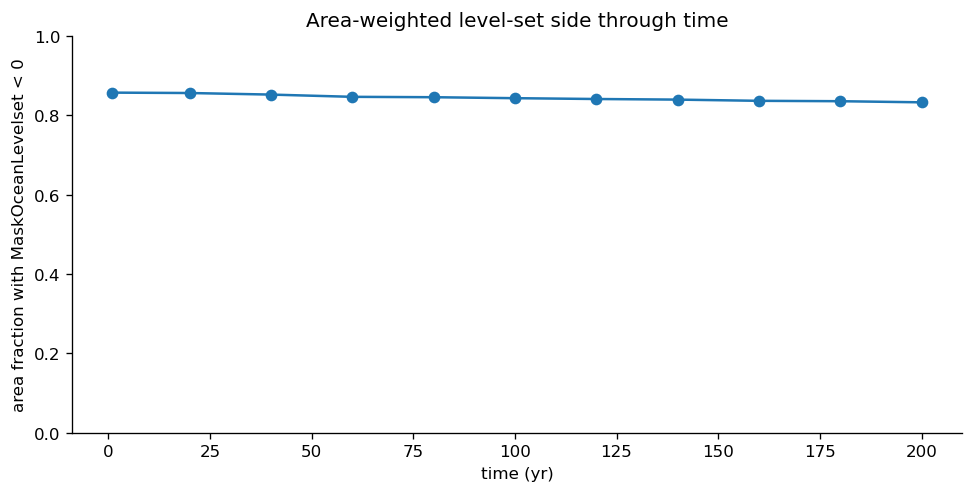

,time_yr,negative_levelset_area_fraction
0,1.0,0.8572
1,20.0,0.8563
2,40.0,0.8523
3,60.0,0.8467
4,80.0,0.8457
5,100.0,0.8432
6,120.0,0.8412
7,140.0,0.8396
8,160.0,0.8366
9,180.0,0.8356


In [10]:
def triangle_areas(x, y, elements):
    xa, ya = x[elements[:, 0]], y[elements[:, 0]]
    xb, yb = x[elements[:, 1]], y[elements[:, 1]]
    xc, yc = x[elements[:, 2]], y[elements[:, 2]]
    return 0.5 * np.abs((xb-xa)*(yc-ya) - (xc-xa)*(yb-ya))

areas = triangle_areas(x, y, elements)
mask = fields['MaskOceanLevelset']
element_mask_mean = np.nanmean(mask[:, elements], axis=2)
negative_fraction = (element_mask_mean < 0) @ areas / areas.sum()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(time, negative_fraction, marker='o')
ax.set_xlabel('time (yr)')
ax.set_ylabel('area fraction with MaskOceanLevelset < 0')
ax.set_ylim(0, 1)
ax.set_title('Area-weighted level-set side through time')
plt.show()

pd.DataFrame({'time_yr': time, 'negative_levelset_area_fraction': negative_fraction}).round(4)

## Centreline profiles

A MISMIP-style model is often easiest to reason about as an along-flow profile. This samples the triangulated fields along the median-y centreline.

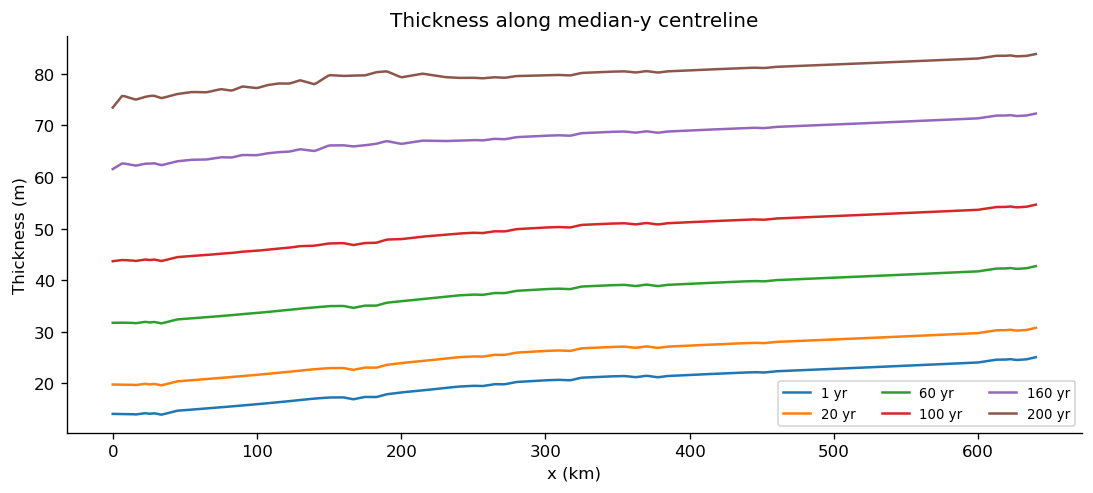

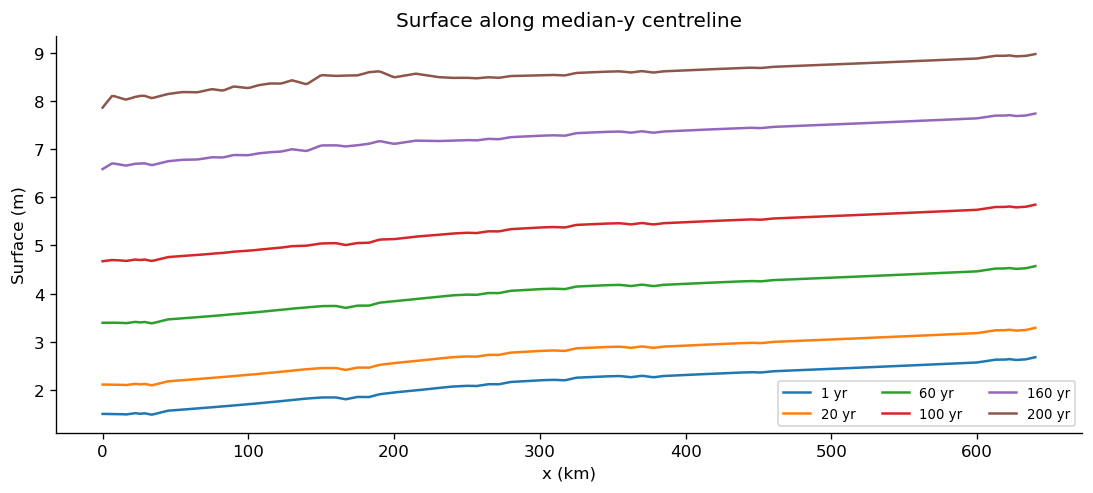

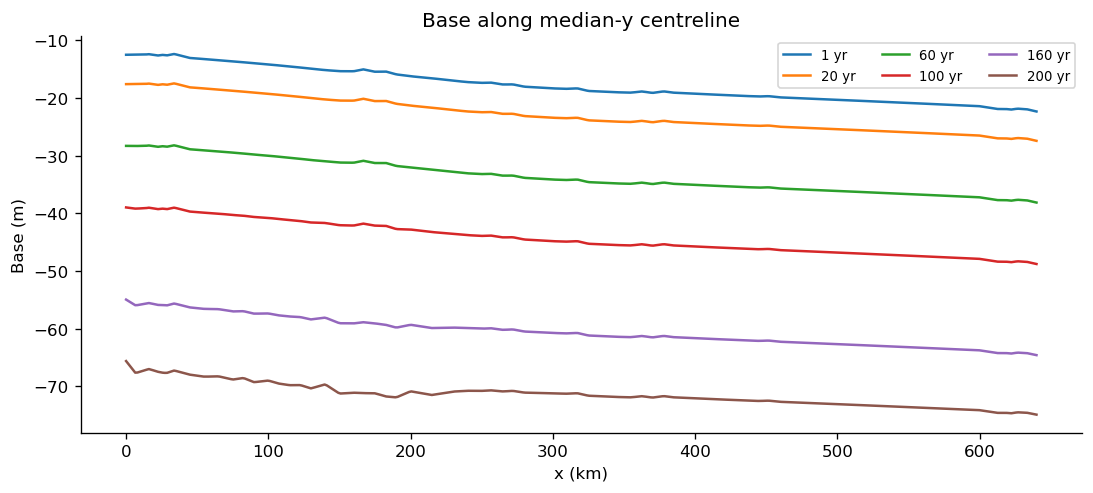

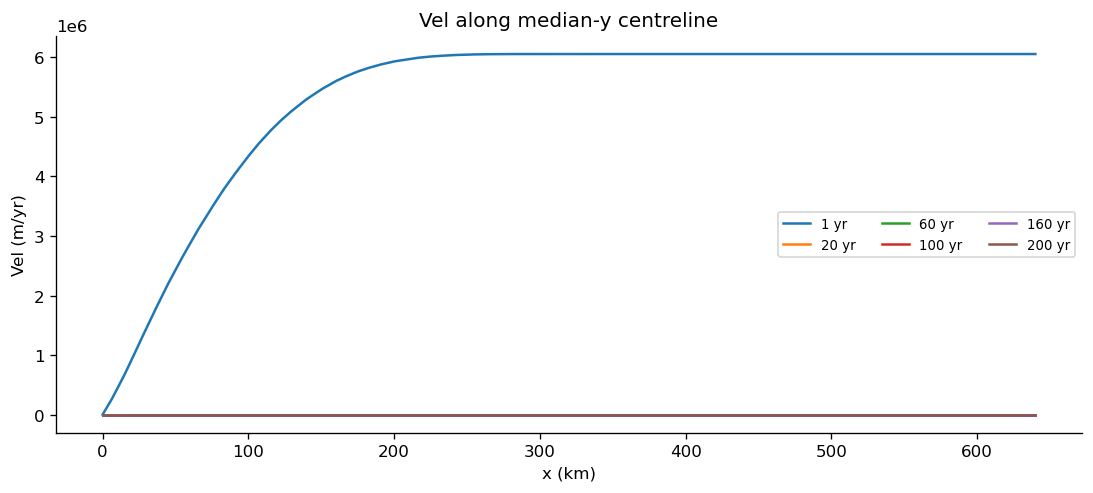

In [11]:
def sample_centerline(field, indices=None, n=400, y0=None):
    if indices is None:
        indices = [0, 1, 3, 5, 8, 10]
    if y0 is None:
        y0 = float(np.nanmedian(y))
    xs = np.linspace(np.nanmin(x), np.nanmax(x), n)
    ys = np.full_like(xs, y0)
    rows = []
    for idx in indices:
        interp = mtri.LinearTriInterpolator(triang, fields[field][idx])
        values = np.asarray(interp(xs, ys), dtype=float)
        rows.append(pd.DataFrame({'x_km': xs/1000, 'y_m': y0, 'time_yr': time[idx], field: values}))
    return pd.concat(rows, ignore_index=True)

def plot_centerline(field, indices=None):
    prof = sample_centerline(field, indices=indices)
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    for t, group in prof.groupby('time_yr'):
        ax.plot(group.x_km, group[field], label=f'{t:g} yr')
    ax.set_xlabel('x (km)')
    ax.set_ylabel(f'{field} ({UNITS.get(field, "")})')
    ax.set_title(f'{field} along median-y centreline')
    ax.legend(ncols=3, fontsize=8)
    return prof, fig, ax

for field in ['Thickness', 'Surface', 'Base', 'Vel']:
    prof, fig, ax = plot_centerline(field)
    plt.show()

## Interactive time browser

If `ipywidgets` is available in the active Jupyter environment, this cell gives a quick field/time browser. Otherwise the static panel examples above still work.

In [ ]:
if widgets is None:
    print('ipywidgets is not installed in this kernel.')
else:
    field_widget = widgets.Dropdown(options=list(fields), value='Thickness', description='Field')
    time_widget = widgets.IntSlider(value=len(time)-1, min=0, max=len(time)-1, step=1, description='Index')
    robust_widget = widgets.Checkbox(value=True, description='Robust colours')

    def browse(field, index, robust):
        fig, ax = plot_field_at_time(field, index=index, robust=robust, show_grounding=True)
        plt.show()

    display(widgets.interactive_output(browse, {'field': field_widget, 'index': time_widget, 'robust': robust_widget}))
    display(widgets.HBox([field_widget, time_widget, robust_widget]))

## Animation examples

The HTML animation is lightweight enough for this 646-vertex mesh. For publication output, uncomment the `anim.save(...)` line and choose `ffmpeg` or `pillow` depending on what is available in your environment.

In [ ]:
def animate_field(field='Thickness', robust=True, cmap='viridis'):
    vmin, vmax = limits_for(fields[field], robust=robust)
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    image = ax.tripcolor(triang, fields[field][0], shading='gouraud', cmap=cmap, vmin=vmin, vmax=vmax)
    contour_holder = {'contour': None}
    fig.colorbar(image, ax=ax, label=f'{field} ({UNITS.get(field, "")})')
    style_map_axis(ax)

    def update(frame):
        ax.clear()
        image = ax.tripcolor(triang, fields[field][frame], shading='gouraud', cmap=cmap, vmin=vmin, vmax=vmax)
        if 'MaskOceanLevelset' in fields:
            ax.tricontour(triang, fields['MaskOceanLevelset'][frame], levels=[0], colors='black', linewidths=0.8)
        style_map_axis(ax, f'{field}, year {time[frame]:g}')
        return [image]

    anim = FuncAnimation(fig, update, frames=len(time), interval=700, blit=False)
    plt.close(fig)
    return anim

anim = animate_field('Thickness', robust=True, cmap='magma')
HTML(anim.to_jshtml())

# To save an animation file:
# anim.save('/g/data/au88/jr5971/MISMIP_ISSM/rundir/mismip_thickness_evolution.mp4', fps=2, dpi=180)

## Solver progress and convergence clues

The NetCDF file only stores `StressbalanceConvergenceNumSteps` as a single value, so the richer convergence story comes from the ISSM outlog. This parser extracts transient iteration times and flags lines where nonlinear iterations exceeded the configured limit.

In [ ]:
def parse_outlog(path):
    if not path.exists():
        return pd.DataFrame(), []
    iter_re = re.compile(r'iteration\s+(\d+)/(\d+)\s+time \[yr\]:\s+([0-9.+-eE]+).*time step:\s+([0-9.+-eE]+)')
    rows = []
    warnings_found = []
    current = None
    for line_no, line in enumerate(path.read_text(errors='replace').splitlines(), start=1):
        match = iter_re.search(line)
        if match:
            current = {
                'line': line_no,
                'iteration': int(match.group(1)),
                'total_iterations': int(match.group(2)),
                'time_yr': float(match.group(3)),
                'dt_yr': float(match.group(4)),
                'nonlinear_limit_exceeded': False,
            }
            rows.append(current)
        if 'maximum number of nonlinear iterations' in line.lower():
            warnings_found.append({'line': line_no, 'message': line.strip(), 'iteration': current['iteration'] if current else np.nan})
            if current:
                current['nonlinear_limit_exceeded'] = True
    return pd.DataFrame(rows), warnings_found

progress, convergence_warnings = parse_outlog(OUTLOG_PATH)
with nc.Dataset(NC_PATH) as ds:
    convergence_steps = np.asarray(ds.groups['results'].groups['TransientSolution'].variables['StressbalanceConvergenceNumSteps'][:])
print(f'NetCDF StressbalanceConvergenceNumSteps: {convergence_steps}')
print(f'Parsed {len(progress)} transient iterations from {OUTLOG_PATH.name if OUTLOG_PATH.exists() else OUTLOG_PATH}')
print(f'Nonlinear-limit warnings: {len(convergence_warnings)}')
display(progress.head())
display(pd.DataFrame(convergence_warnings).head(20))

if len(progress):
    fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
    ax.plot(progress.iteration, progress.time_yr, color='0.35')
    bad = progress[progress.nonlinear_limit_exceeded]
    ax.scatter(bad.iteration, bad.time_yr, color='tab:red', zorder=3, label='nonlinear limit exceeded')
    for saved_time in time:
        ax.axhline(saved_time, color='tab:blue', alpha=0.12, linewidth=1)
    ax.set_xlabel('transient iteration')
    ax.set_ylabel('model time (yr)')
    ax.set_title('Outlog progress with saved NetCDF output times')
    ax.legend()
    plt.show()